In [ ]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
from numba import njit
from pathlib import Path
import sys

# ==========================================
# 0. CONFIGURATION DES CHEMINS
# ==========================================
notebook_dir = Path.cwd()
project_root = notebook_dir.parent 
sys.path.append(str(project_root))

from mpp_project.core import apply_heteroscedastic_noise, apply_temporal_drift, estimate_crowd_3D, calculate_true_outcome_probas_from_odds
# Assure-toi d'avoir remis la fonction d'extraction classique 1D dans oracle_dp.py
from mpp_project.v5_supervised.oracle_dp import extract_peloton_full_distribution, compute_alphas_isolement, N_PLAYERS

# --- PARAMÈTRES DE LA CALIBRATION ---
N_RUNS_EXTRACTION = 3_000_000
N_RUNS_SANITY_CHECK = 400_000
COEFF_ROBUSTESSE = 1.25   # Facteur multiplicatif sur N_PLAYERS pour simuler bonus x2
SEUIL_ISOLEMENT = 80.0    # Écart-type (points) pour le Gating Temporel (alpha) (en cas de depassement, moyenne ponderee entre Bob (alpha) et peloton (1-alpha))



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [81]:
# ==========================================
# 1. CHARGEMENT ET PRÉPARATION DES DONNÉES
# ==========================================
print("Chargement des données CDM_2026.csv...")
df = pd.read_csv(project_root / "data" / "CDM_2026.csv")
match_phases = df['phase'].tolist()
n_matches = len(df)

odds = df[['cote_1', 'cote_N', 'cote_2']].values.astype(np.float64)
base_true_probas = calculate_true_outcome_probas_from_odds(odds)

base_crowds = df[['crowd_1', 'crowd_N', 'crowd_2']].values.astype(np.float64)
base_crowds = base_crowds / base_crowds.sum(axis=1, keepdims=True)

gains_1N2 = df[['gain_mpp_1', 'gain_mpp_N', 'gain_mpp_2']].values.astype(np.int32)
max_gain_dynamique = min(250, np.max(gains_1N2) + 1)

# Bruit bayésien
dists = np.arange(n_matches)
dists_positive = np.maximum(0, dists)
alphas_bayes = 0.95 * (0.5 ** (dists_positive / 5.0))
alphas_2d = alphas_bayes.astype(np.float32)[:, np.newaxis]

c1, cN, c2 = estimate_crowd_3D(base_true_probas[:, 0], base_true_probas[:, 1], base_true_probas[:, 2], add_noise=False)
theo_crowds_pure = np.column_stack((c1, cN, c2)).astype(np.float32)
blended_mean_crowds = (alphas_2d * base_crowds) + ((1.0 - alphas_2d) * theo_crowds_pure)
dynamic_rmse = 0.083 * (1.0 - alphas_2d)

Chargement des données CDM_2026.csv...


In [ ]:
print("\nCalcul de la transition de phase du peloton (Alphas d'isolement)...")
alphas_isolement = compute_alphas_isolement(base_true_probas, base_crowds, gains_1N2, SEUIL_ISOLEMENT)




Calcul de la transition de phase du peloton (Alphas d'isolement)...


In [83]:
# ==========================================
# 3. GÉNÉRATION DU MULTIVERS
# ==========================================
N_UNIVERSES = 1000
print(f"\nGénération du Multivers de Drift ({N_UNIVERSES} univers)...")
start = time.time()

true_probas_3d = np.zeros((N_UNIVERSES, n_matches, 3), dtype=np.float64)
crowds_3d = np.zeros((N_UNIVERSES, n_matches, 3), dtype=np.float64)

for u in range(N_UNIVERSES):
    true_probas_3d[u] = apply_temporal_drift(base_true_probas, match_phases, current_match_idx=0)
    crowds_3d[u] = apply_heteroscedastic_noise(blended_mean_crowds, rmse=dynamic_rmse)
    
print(f"-> Multivers généré en {time.time() - start:.2f} s.")

# ==========================================
# 4. EXTRACTION PURE DU PELOTON (1D)
# ==========================================
n_players_simules = int(round((N_PLAYERS - 1) * COEFF_ROBUSTESSE))

print(f"\nExtraction de l'histogramme du peloton ({N_RUNS_EXTRACTION:,} runs)...")
print(f"-> Joueurs simulés : {N_PLAYERS - 1} vrais + {n_players_simules - (N_PLAYERS - 1)} virtuels (Robustesse) = {n_players_simules}")

start = time.time()
p_empirique_1D = extract_peloton_full_distribution(
    true_probas_3d=true_probas_3d, 
    crowds_3d=crowds_3d, 
    gains_1N2=gains_1N2, 
    max_gain=max_gain_dynamique, 
    n_runs=N_RUNS_EXTRACTION, 
    n_players=n_players_simules
)
print(f"-> Extraction terminée en {time.time() - start:.2f} s.")





Génération du Multivers de Drift (1000 univers)...
-> Multivers généré en 1.50 s.

Extraction de l'histogramme du peloton (3,000,000 runs)...
-> Joueurs simulés : 11 vrais + 3 virtuels (Robustesse) = 14
-> Extraction terminée en 77.72 s.


In [84]:
# ==========================================
# 5. FONCTION DE SANITY CHECK (Gating Temporel)
# ==========================================
@njit
def run_calibration_test_pure(true_probas, crowds, gains_1N2, p_empirique_1D, alphas, n_runs=300000):
    n_matches = true_probas.shape[0]
    max_gain = p_empirique_1D.shape[2]
    
    wins_agent = 0.0
    wins_opponents = 0.0
    
    for run in range(n_runs):
        gap1 = 0
        gap2 = 0
        
        for t in range(n_matches):
            alpha = alphas[t]
            
            # Réalité
            r_true = np.random.rand()
            if r_true < true_probas[t, 0]: true_out = 0
            elif r_true < true_probas[t, 0] + true_probas[t, 1]: true_out = 1
            else: true_out = 2
            true_gain = gains_1N2[t, true_out]
            
            # Agent
            r_agent = np.random.rand()
            if r_agent < crowds[t, 0]: bet_agent = 0
            elif r_agent < crowds[t, 0] + crowds[t, 1]: bet_agent = 1
            else: bet_agent = 2
            gain_agent = true_gain if bet_agent == true_out else 0
            
            # Bob
            r_bob = np.random.rand()
            if r_bob < crowds[t, 0]: bet_bob = 0
            elif r_bob < crowds[t, 0] + crowds[t, 1]: bet_bob = 1
            else: bet_bob = 2
            gain_bob = true_gain if bet_bob == true_out else 0
            
            # Peloton
            r_peloton = np.random.rand()
            cum_p = 0.0
            delta_gain = 0
            for g in range(max_gain):
                cum_p += p_empirique_1D[t, true_out, g]
                if r_peloton <= cum_p:
                    delta_gain = g
                    break
                    
            new_gap_bob = gap1 + gain_agent - gain_bob
            new_gap_peloton = gap2 + gain_agent - delta_gain
            
            # 🚀 LE TRI AVEC GATING TEMPOREL (La Physique Réelle)
            gap1 = min(new_gap_bob, new_gap_peloton)
            gap2 = alpha * max(new_gap_bob, new_gap_peloton) + (1.0 - alpha) * new_gap_peloton
            
        # Condition Terminale
        if gap1 > 0 and gap2 > 0: wins_agent += 1.0
        elif gap1 == 0 and gap2 > 0: wins_agent += 0.5; wins_opponents += 0.5
        elif gap1 == 0 and gap2 == 0: wins_agent += 1.0 / 3.0; wins_opponents += 2.0 / 3.0
        else: wins_opponents += 1.0
            
    return wins_agent / n_runs, wins_opponents / n_runs


# ==========================================
# 6. EXECUTION DU SANITY CHECK
# ==========================================
print(f"\nLancement du Sanity Check ({N_RUNS_SANITY_CHECK:,} tournois)...")
start_calib = time.time()

# On utilise l'univers 0 (le scénario moyen)
wr_agent, wr_opp = run_calibration_test_pure(
    true_probas=true_probas_3d[0], 
    crowds=crowds_3d[0], 
    gains_1N2=gains_1N2, 
    p_empirique_1D=p_empirique_1D, 
    alphas=alphas_isolement,
    n_runs=N_RUNS_SANITY_CHECK
)

elapsed = time.time() - start_calib
print(f"-> Test terminé en {elapsed:.2f} secondes.\n")

print("=== RÉSULTATS DU SANITY CHECK ===")
print(f"🏆 Win Rate de l'Agent (Jeu Aléatoire) : {wr_agent*100:.2f}%")
print(f"🥇 Win Rate des Adversaires virtuels   : {wr_opp*100:.2f}%")


# ==========================================
# 7. EXPORTATION POUR LE NIGHT MODE
# ==========================================
print("\nSauvegarde de la matrice pour Colab/Téléphone...")
np.save(project_root / "data" / "p_empirique_1D.npy", p_empirique_1D)
print("✅ Fichier 'p_empirique_1D.npy' généré avec succès !")





Lancement du Sanity Check (400,000 tournois)...
-> Test terminé en 5.22 secondes.

=== RÉSULTATS DU SANITY CHECK ===
🏆 Win Rate de l'Agent (Jeu Aléatoire) : 7.43%
🥇 Win Rate des Adversaires virtuels   : 92.57%

Sauvegarde de la matrice pour Colab/Téléphone...
✅ Fichier 'p_empirique_1D.npy' généré avec succès !



Lancement des simulations pour les graphiques...


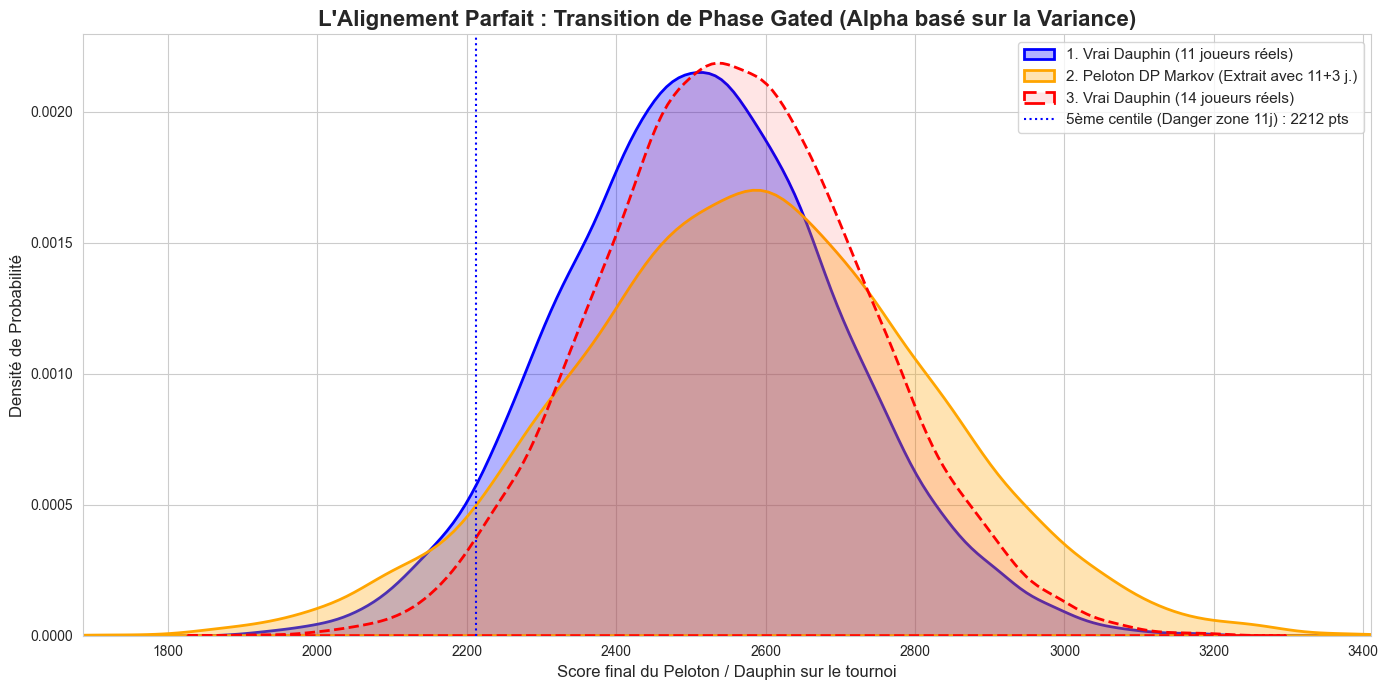

In [85]:
# ==========================================
# 8. CELLULE DE VISUALISATION (DIAGNOSTIC)
# ==========================================
@njit
def get_real_meute_final_scores(true_probas, crowds, gains_1N2, n_players, n_runs=10000):
    n_matches = true_probas.shape[0]
    final_scores = np.zeros(n_runs, dtype=np.int32)
    for run in range(n_runs):
        scores = np.zeros(n_players, dtype=np.int32)
        for t in range(n_matches):
            r_true = np.random.rand()
            if r_true < true_probas[t, 0]: true_out = 0
            elif r_true < true_probas[t, 0] + true_probas[t, 1]: true_out = 1
            else: true_out = 2
            true_gain = gains_1N2[t, true_out]
            
            for i in range(n_players):
                r_bet = np.random.rand()
                if r_bet < crowds[t, 0]: bet = 0
                elif r_bet < crowds[t, 0] + crowds[t, 1]: bet = 1
                else: bet = 2
                if bet == true_out: scores[i] += true_gain
        scores.sort()
        final_scores[run] = scores[-2]
    return final_scores

@njit
def get_markov_peloton_final_scores_pure(true_probas, crowds, gains_1N2, p_empirique_1D, alphas, n_runs=10000):
    n_matches = true_probas.shape[0]
    max_gain = p_empirique_1D.shape[2]
    final_scores_2nd = np.zeros(n_runs, dtype=np.int32)
    
    for run in range(n_runs):
        score_bob = 0
        score_pel = 0
        for t in range(n_matches):
            alpha = alphas[t]
            
            r_true = np.random.rand()
            if r_true < true_probas[t, 0]: true_out = 0
            elif r_true < true_probas[t, 0] + true_probas[t, 1]: true_out = 1
            else: true_out = 2
            true_gain = gains_1N2[t, true_out]
            
            r_bob = np.random.rand()
            if r_bob < crowds[t, 0]: bet_bob = 0
            elif r_bob < crowds[t, 0] + crowds[t, 1]: bet_bob = 1
            else: bet_bob = 2
            gain_bob = true_gain if bet_bob == true_out else 0
            
            r_peloton = np.random.rand()
            cum_p = 0.0
            delta_gain = 0
            for g in range(max_gain):
                cum_p += p_empirique_1D[t, true_out, g]
                if r_peloton <= cum_p:
                    delta_gain = g
                    break
                    
            new_bob = score_bob + gain_bob
            new_pel = score_pel + delta_gain
            
            # 🚀 L'ÉQUIVALENCE MATHÉMATIQUE ABSOLUE DES GAPS
            score_bob = max(new_bob, new_pel)
            score_pel = alpha * min(new_bob, new_pel) + (1.0 - alpha) * new_pel
            
        final_scores_2nd[run] = score_pel
    return final_scores_2nd


print("\nLancement des simulations pour les graphiques...")
univ_probas = true_probas_3d[0]
univ_crowds = crowds_3d[0]

scores_real_11 = get_real_meute_final_scores(univ_probas, univ_crowds, gains_1N2, n_players=N_PLAYERS-1, n_runs=10000)
scores_real_16 = get_real_meute_final_scores(univ_probas, univ_crowds, gains_1N2, n_players=n_players_simules, n_runs=10000)
scores_markov_16 = get_markov_peloton_final_scores_pure(univ_probas, univ_crowds, gains_1N2, p_empirique_1D, alphas_isolement, n_runs=10000)

plt.figure(figsize=(14, 7))
sns.set_style("whitegrid")

sns.kdeplot(scores_real_11, color="blue", fill=True, alpha=0.3, linewidth=2, label=f"1. Vrai Dauphin ({N_PLAYERS-1} joueurs réels)")
sns.kdeplot(scores_markov_16, color="orange", fill=True, alpha=0.3, linewidth=2, label=f"2. Peloton DP Markov (Extrait avec {N_PLAYERS-1}+{n_players_simules - (N_PLAYERS - 1)} j.)")
sns.kdeplot(scores_real_16, color="red", fill=True, alpha=0.1, linewidth=2, linestyle="--", label=f"3. Vrai Dauphin ({n_players_simules} joueurs réels)")

plt.title("L'Alignement Parfait : Transition de Phase Gated (Alpha basé sur la Variance)", fontsize=16, fontweight='bold')
plt.xlabel("Score final du Peloton / Dauphin sur le tournoi", fontsize=12)
plt.ylabel("Densité de Probabilité", fontsize=12)

p5_11 = np.percentile(scores_real_11, 5)
plt.axvline(x=p5_11, color='blue', linestyle=':', label=f"5ème centile (Danger zone {N_PLAYERS-1}j) : {int(p5_11)} pts")

plt.legend(fontsize=11, loc="upper right")
plt.xlim(min(scores_real_11)-200, max(scores_real_16)+200)
plt.tight_layout()
plt.show()